In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv("bank-additional-full.csv",sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [14]:
df.shape

(41199, 21)

In [15]:
df.isnull().sum()

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64

In [16]:
df.isnull().sum().sum()

np.int64(76)

In [17]:
df = df.dropna()

In [18]:
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=df[col].fillna(df[col].mode([0]))
    else:
        df[col]=df[col].fillna(df[col].mean())    

C:\Users\ARYAN SHARMA\AppData\Local\Temp\ipykernel_9932\114595531.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=df[col].fillna(df[col].mean())
C:\Users\ARYAN SHARMA\AppData\Local\Temp\ipykernel_9932\114595531.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=df[col].fillna(df[col].mode([0]))


In [19]:
df.duplicated().sum()

np.int64(13)

In [20]:
df=df.drop_duplicates()

In [21]:
df.fillna(df.mean(numeric_only=True), inplace=True)

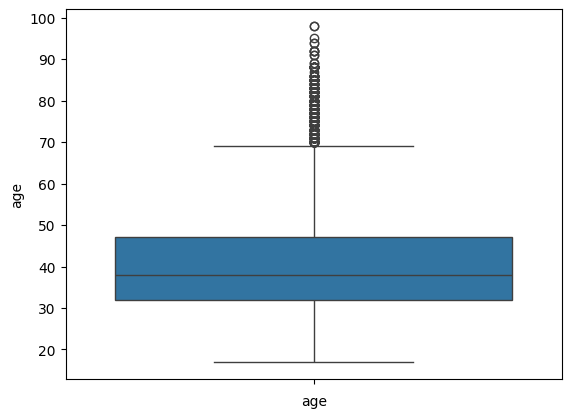

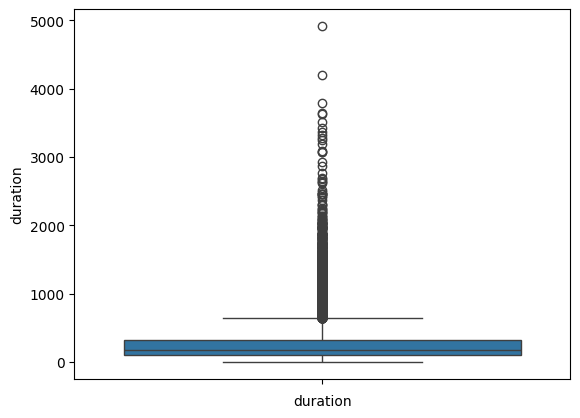

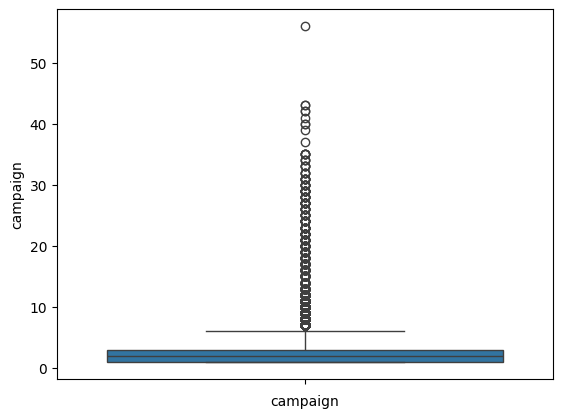

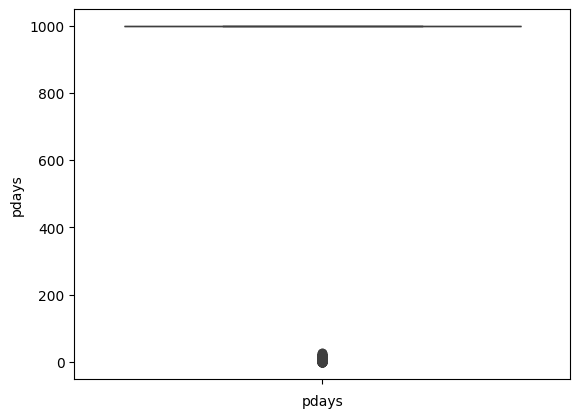

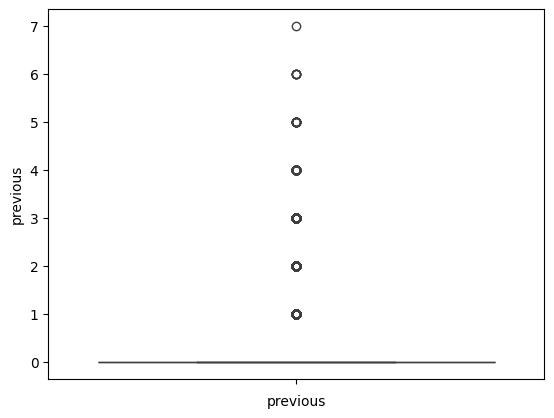

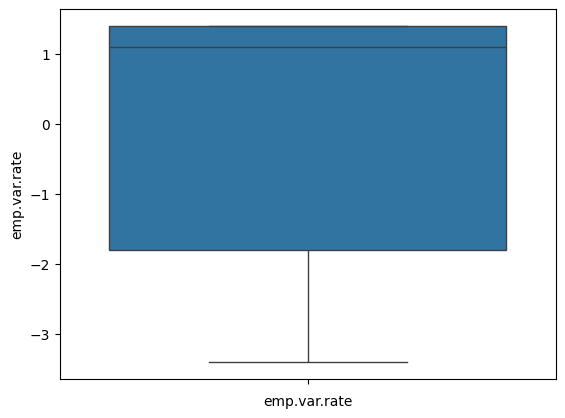

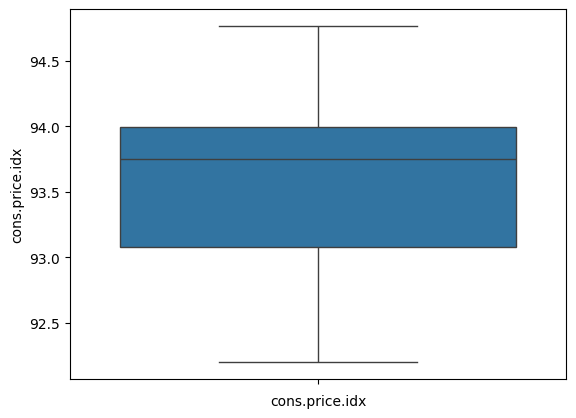

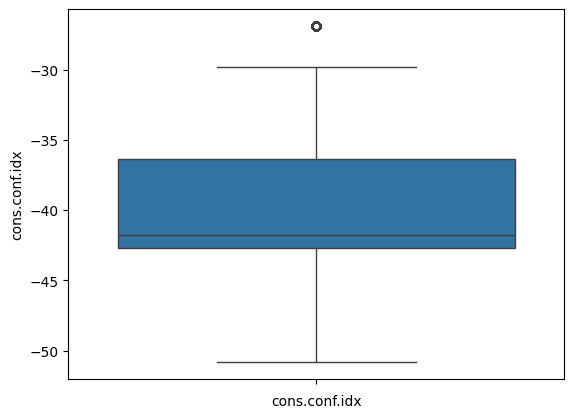

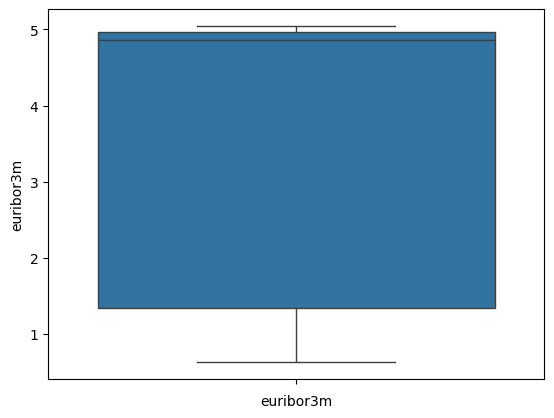

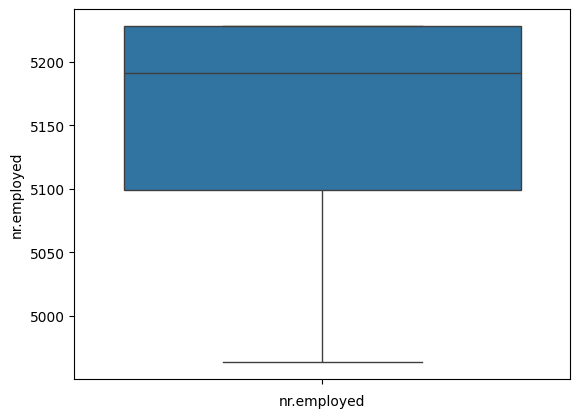

In [22]:
## creating boxplot for  columns
for i in df.columns:
    if (df[i].dtypes=='int64' or df[i].dtypes=='float64'):
        sns.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [23]:
q1=df['age'].quantile(0.25)
q3=df['age'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr
df=df[(df['age']>lower) & (df['age']<upper)]

In [24]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtypes=="object":
        df[col]=le.fit_transform(df[col])

In [25]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,0,1,6,0,2,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41182,29.0,10,2,0,0,2,0,0,7,0,...,1.0,9.0,1.0,2,-1.1,94.767,-50.8,1.028,4963.6,0
41184,46.0,1,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56.0,5,1,6,0,2,0,0,7,0,...,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0


***Variance Inflation Factor (IVF)*** 
it is used in the case of multipolinarity where multiple features gives the same information
if the value of ivf comes btw  5 to 6 - then multipolinarity is  manageable .
if the value of ivf comes     <5 - then multipolinarity is  very less.
if the value of ivf comes >6 - then i have to drop those features which are repetitive.

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

col_list = []

for i in df.columns:
    if (df[i].dtype!= 'object') and (i != 'y'):
        col_list.append(i)

x = df[col_list]

vif = pd.DataFrame()
vif['column_name'] = x.columns
vif['VIF_Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

vif

,column_name,VIF_Score
0,age,22.008695
1,job,2.102466
2,marital,5.696930
3,education,4.541063
4,default,1.414062
5,housing,2.204812
6,loan,1.207929
7,contact,2.895702
8,month,6.859569
9,day_of_week,3.085333


In [27]:
print(x.shape)

(40708, 20)


***RFE***

recursive feature elimination

In [40]:
x=df.iloc[: ,:-1]
y=df.iloc[:,-1]


In [41]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,0,1,6,0,2,0,0,7,0,281.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29.0,10,2,0,0,2,0,0,7,0,112.0,1.0,9.0,1.0,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46.0,1,1,5,0,0,0,0,7,0,383.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56.0,5,1,6,0,2,0,0,7,0,189.0,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6


In [42]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41181    1
41182    0
41184    0
41185    0
41186    1
Name: y, Length: 40708, dtype: int64

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model=LogisticRegression()

In [46]:
from sklearn.feature_selection  import RFE

In [47]:
rfe=RFE(model)

In [48]:
rfe.fit(x,y)

C:\Users\ARYAN SHARMA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ARYAN SHARMA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

,estimator,LogisticRegression()
,n_features_to_select,None
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [49]:
rfe.support_

array([False, False,  True,  True,  True, False, False,  True, False,
        True, False,  True, False,  True,  True,  True, False, False,
        True, False])

In [52]:
selected_indices=[i for i , data in enumerate(rfe.support_) if data==True]
selected_indices

[2, 3, 4, 7, 9, 11, 13, 14, 15, 18]

In [55]:
column_name=x.columns

In [57]:
selected_columns=[column_name[i] for i in selected_indices]

In [58]:
selected_columns

['marital',
 'education',
 'default',
 'contact',
 'day_of_week',
 'campaign',
 'previous',
 'poutcome',
 'emp.var.rate',
 'euribor3m']

In [61]:
x=x.loc[:,['marital','education','default','contact','day_of_week', 'campaign','previous', 'poutcome','emp.var.rate','euribor3m']]

In [62]:
x

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,emp.var.rate,euribor3m
0,1,0,0,1,1,1.0,0.0,1,1.1,4.857
1,1,3,1,1,1,1.0,0.0,1,1.1,4.857
2,1,3,0,1,1,1.0,0.0,1,1.1,4.857
3,1,1,0,1,1,1.0,0.0,1,1.1,4.857
4,1,3,0,1,1,1.0,0.0,1,1.1,4.857
...,...,...,...,...,...,...,...,...,...,...
41181,1,6,0,0,0,1.0,0.0,1,-1.1,1.028
41182,2,0,0,0,0,1.0,1.0,2,-1.1,1.028
41184,1,5,0,0,0,1.0,0.0,1,-1.1,1.028
41185,1,6,0,0,0,2.0,0.0,1,-1.1,1.028


In [63]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41181    1
41182    0
41184    0
41185    0
41186    1
Name: y, Length: 40708, dtype: int64

In [64]:
from sklearn.model_selection import train_test_split

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [66]:
x_train

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,emp.var.rate,euribor3m
29270,1,2,0,0,0,2.0,1.0,0,-1.8,1.405
11542,1,3,0,1,0,3.0,0.0,1,1.4,4.959
36570,2,6,1,0,4,2.0,1.0,0,-2.9,1.260
5158,1,0,1,1,0,5.0,0.0,1,1.1,4.857
13392,1,1,0,0,4,1.0,0.0,1,1.4,4.962
...,...,...,...,...,...,...,...,...,...,...
6266,1,2,0,1,3,2.0,0.0,1,1.1,4.857
11285,1,2,0,1,2,1.0,0.0,1,1.4,4.961
38380,1,5,0,0,1,1.0,2.0,0,-3.4,0.739
860,1,6,0,1,4,2.0,0.0,1,1.1,4.856


In [69]:
x_test

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,emp.var.rate,euribor3m
5713,1,0,0,1,1,6.0,0.0,1,1.1,4.857
6947,2,3,0,1,2,1.0,0.0,1,1.1,4.860
29780,0,6,1,0,1,2.0,1.0,0,-1.8,1.405
18706,2,3,0,0,2,6.0,0.0,1,1.4,4.968
40891,1,5,0,0,0,1.0,2.0,2,-1.1,0.972
...,...,...,...,...,...,...,...,...,...,...
20397,1,6,0,0,3,1.0,0.0,1,1.4,4.966
33468,2,2,0,0,3,3.0,0.0,1,-1.8,1.291
35012,1,1,1,0,0,1.0,0.0,1,-1.8,1.250
34270,2,3,0,0,2,8.0,1.0,0,-1.8,1.266


In [70]:
y_train

29270    0
11542    0
36570    0
5158     0
13392    0
        ..
6266     0
11285    0
38380    0
860      0
15798    0
Name: y, Length: 32566, dtype: int64

In [71]:
y_test

5713     0
6947     0
29780    0
18706    0
40891    1
        ..
20397    0
33468    1
35012    0
34270    0
34332    0
Name: y, Length: 8142, dtype: int64

In [72]:
from sklearn.linear_model import LogisticRegression

In [73]:
lr=LogisticRegression()

In [74]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
y_pred=lr.predict(x_test)

In [77]:
new_df=pd.DataFrame()
new_df['Actual_value']=y_test
new_df['Predicted_value']=y_pred

In [78]:
new_df

,Actual_value,Predicted_value
5713,0,0
6947,0,0
29780,0,0
18706,0,0
40891,1,1
...,...,...
20397,0,0
33468,1,0
35012,0,0
34270,0,0


In [83]:
from sklearn.metrics import *

In [84]:
accuracy_score(y_test,y_pred)

0.9011299435028248